# B Locus Clustering Analysis with ESM Encoder

This notebook encodes the alleles at the B locus using the ESM encoder, performs clustering on the embeddings, and compares the cluster labels to the serological groupings (e.g. B*01, B*02, etc.).

In [1]:
# Setup environment
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch

# Add parent directory to sys.path
notebook_dir = Path().resolve()
project_dir = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
sys.path.insert(0, str(project_dir))

# Set paths
data_dir = project_dir / 'data'
embeddings_dir = data_dir / 'embeddings'
sequence_dir = data_dir / 'raw' / 'sequences'
cache_dir = embeddings_dir / 'esm_cache'

In [2]:
# Import the ESM encoder
from src.models.encoders.esm import ESMEncoder

# Load B locus sequences
sequence_file = data_dir / 'processed' / 'hla_sequences.pkl'

# Initialize ESM encoder for B locus
print("Initializing ESM encoder for B locus...")
encoder = ESMEncoder(
    sequence_file=sequence_file,
    cache_dir=str(cache_dir),
    locus='B',
    model_name="facebook/esm2_t33_650M_UR50D",
    pooling_strategy="mean",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {encoder.device}")
print(f"Model: {encoder.model_name}")
print(f"Pooling strategy: {encoder.pooling_strategy}")

py-ard not installed; allele resolution mapping will be limited


Initializing ESM encoder for B locus...
Using device: cpu
Model: facebook/esm2_t33_650M_UR50D
Pooling strategy: mean


In [3]:
# Get all B locus alleles
b_alleles = [allele for allele in encoder.sequences.keys() if allele.startswith('B*')]
print(f"Found {len(b_alleles)} B locus alleles")

# Encode all B locus alleles
print("\nEncoding B locus alleles...")
embeddings = encoder.batch_encode_alleles(b_alleles, batch_size=32, force=False)

# Show some basic stats
if embeddings:
    allele = list(embeddings.keys())[0]
    embedding = embeddings[allele]
    print(f"\nSample allele: {allele}")
    print(f"Embedding shape: {embedding.shape}")
    print(f"First 5 dimensions: {embedding[:5]}")

Found 6584 B locus alleles

Encoding B locus alleles...


Encoding (ESM - Transformers): 100%|██████████| 206/206 [1:00:05<00:00, 17.50s/it]



Sample allele: B*07:02
Embedding shape: (1280,)
First 5 dimensions: [-0.01800567 -0.02018547 -0.02160762  0.13730617 -0.0527705 ]


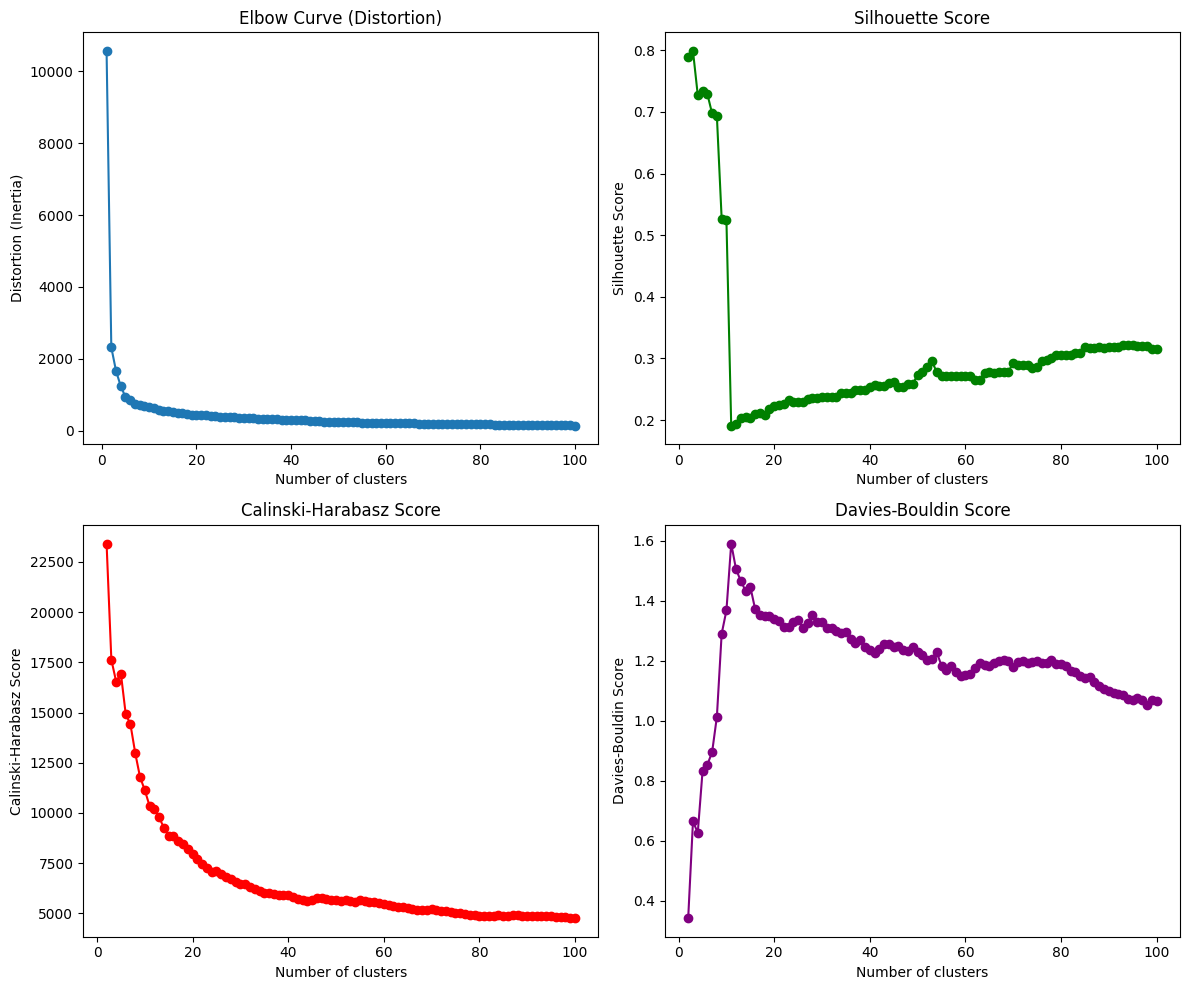

Optimal number of clusters based on silhouette score: 3


In [4]:
# Clustering analysis with multiple metrics
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def cluster_embeddings(embeddings, max_clusters=36):
    # Convert embeddings to array
    X = np.array(list(embeddings.values()))

    distortions = []
    silhouette_scores = []
    calinski_scores = []
    davies_scores = []

    # Loop over possible number of clusters from 1 to max_clusters
    for i in range(1, max_clusters+1):
        kmeans = KMeans(n_clusters=i, random_state=0).fit(X)
        distortions.append(kmeans.inertia_)
        if i > 1:
            labels = kmeans.labels_
            silhouette = silhouette_score(X, labels)
            calinski = calinski_harabasz_score(X, labels)
            davies = davies_bouldin_score(X, labels)
            silhouette_scores.append(silhouette)
            calinski_scores.append(calinski)
            davies_scores.append(davies)
        else:
            # For 1 cluster these metrics are undefined; insert NaN for alignment.
            silhouette_scores.append(np.nan)
            calinski_scores.append(np.nan)
            davies_scores.append(np.nan)

    cluster_range = range(1, max_clusters+1)
    # Metrics computed for cluster counts from 2 to max_clusters (ignoring cluster==1 for non-inertia metrics)
    cluster_range_metrics = range(2, max_clusters+1)

    # Plot metrics in a grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Elbow Curve (Distortion/Inertia)
    axes[0, 0].plot(cluster_range, distortions, marker='o')
    axes[0, 0].set_title('Elbow Curve (Distortion)')
    axes[0, 0].set_xlabel('Number of clusters')
    axes[0, 0].set_ylabel('Distortion (Inertia)')

    # Silhouette Score
    axes[0, 1].plot(cluster_range_metrics, silhouette_scores[1:], marker='o', color='green')
    axes[0, 1].set_title('Silhouette Score')
    axes[0, 1].set_xlabel('Number of clusters')
    axes[0, 1].set_ylabel('Silhouette Score')

    # Calinski-Harabasz Score
    axes[1, 0].plot(cluster_range_metrics, calinski_scores[1:], marker='o', color='red')
    axes[1, 0].set_title('Calinski-Harabasz Score')
    axes[1, 0].set_xlabel('Number of clusters')
    axes[1, 0].set_ylabel('Calinski-Harabasz Score')

    # Davies-Bouldin Score (lower is better)
    axes[1, 1].plot(cluster_range_metrics, davies_scores[1:], marker='o', color='purple')
    axes[1, 1].set_title('Davies-Bouldin Score')
    axes[1, 1].set_xlabel('Number of clusters')
    axes[1, 1].set_ylabel('Davies-Bouldin Score')

    plt.tight_layout()
    plt.show()

    # Select optimal number of clusters based on maximum silhouette score (skip cluster 1)
    best_index = np.nanargmax(silhouette_scores[1:])
    optimal_clusters = best_index + 2  # +2 accounts for starting at 2 clusters
    print(f"Optimal number of clusters based on silhouette score: {optimal_clusters}")

    # Fit and return KMeans with 25 clusters (as in the original notebook)
    kmeans = KMeans(n_clusters=25, random_state=0).fit(X)
    return kmeans

# Cluster embeddings
kmeans = cluster_embeddings(embeddings, max_clusters=100)

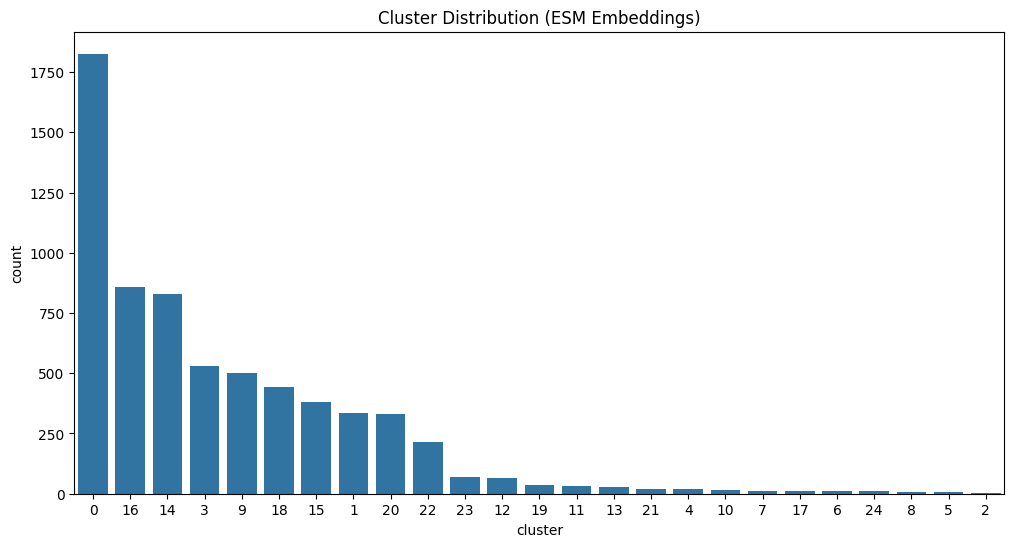

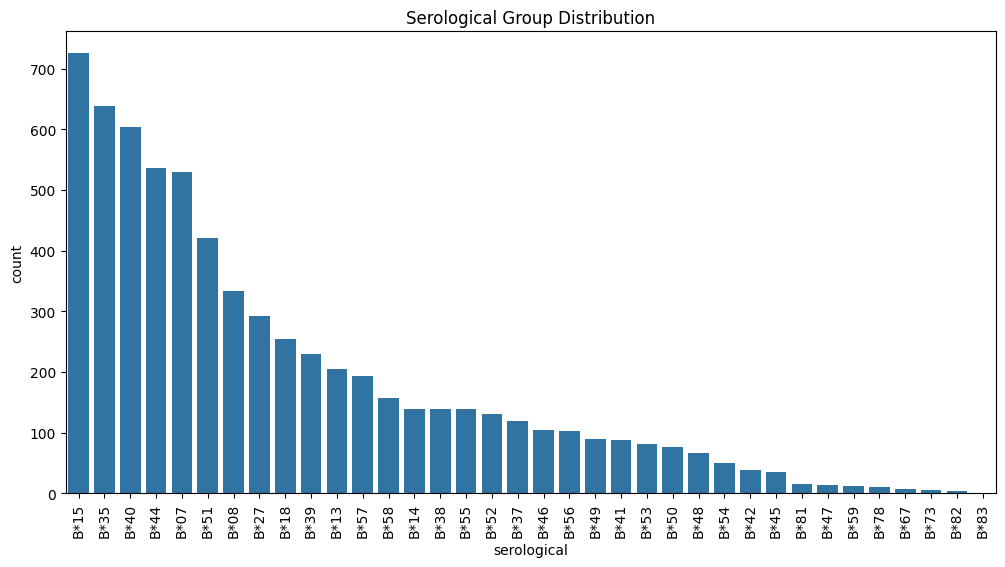

In [5]:
# Compare clusters to serological groups
all_alleles = list(embeddings.keys())
# Load serological name (name of allele up to first ':')
serological_mapping = [allele.split(':')[0] for allele in all_alleles]
# Get cluster labels
cluster_labels = kmeans.labels_

# Create a DataFrame with allele, serological group, and cluster label
df = pd.DataFrame({'allele': all_alleles, 'serological': serological_mapping, 'cluster': cluster_labels})
df = df.sort_values('cluster')

# Plot cluster distribution
plt.figure(figsize=(12, 6))
# sort by count
sns.countplot(x='cluster', data=df, order=df['cluster'].value_counts().index)
plt.title('Cluster Distribution (ESM Embeddings)')
plt.show()

# Plot serological group distribution
plt.figure(figsize=(12, 6))
# labels should be vertical
plt.xticks(rotation=90)
# sort by count
sns.countplot(x='serological', data=df, order=df['serological'].value_counts().index)
plt.title('Serological Group Distribution')
plt.show()

In [6]:
# Cross tabulation of serological group and cluster
ct = pd.crosstab(df['serological'], df['cluster'])

# Print the crosstab
print("Cross-tabulation of serological groups and clusters:")
ct

Cross-tabulation of serological groups and clusters:


cluster,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
serological,,,,,,,,,,,,,,,,,,,,,
B*07,0,0,0,23,2,1,1,1,0,0,...,0,2,0,1,5,176,3,11,7,1
B*08,1,0,0,11,2,0,0,1,0,0,...,0,2,1,1,1,113,2,1,3,0
B*13,102,8,0,29,1,0,1,0,0,2,...,48,5,0,0,4,0,0,3,1,0
B*14,1,0,0,5,0,1,1,0,0,43,...,0,0,1,0,0,0,0,1,2,1
B*15,24,0,0,70,1,0,1,1,1,14,...,21,363,0,163,3,0,1,24,7,1
B*18,143,0,0,10,0,0,0,0,0,0,...,0,4,0,89,0,0,0,2,0,1
B*27,150,0,0,15,4,0,0,0,0,91,...,0,1,1,0,1,0,1,16,5,1
B*35,344,10,0,43,1,0,0,1,2,57,...,3,11,3,127,2,0,1,14,8,2
B*37,58,22,0,8,1,0,0,0,0,15,...,0,0,0,2,1,0,2,4,0,1


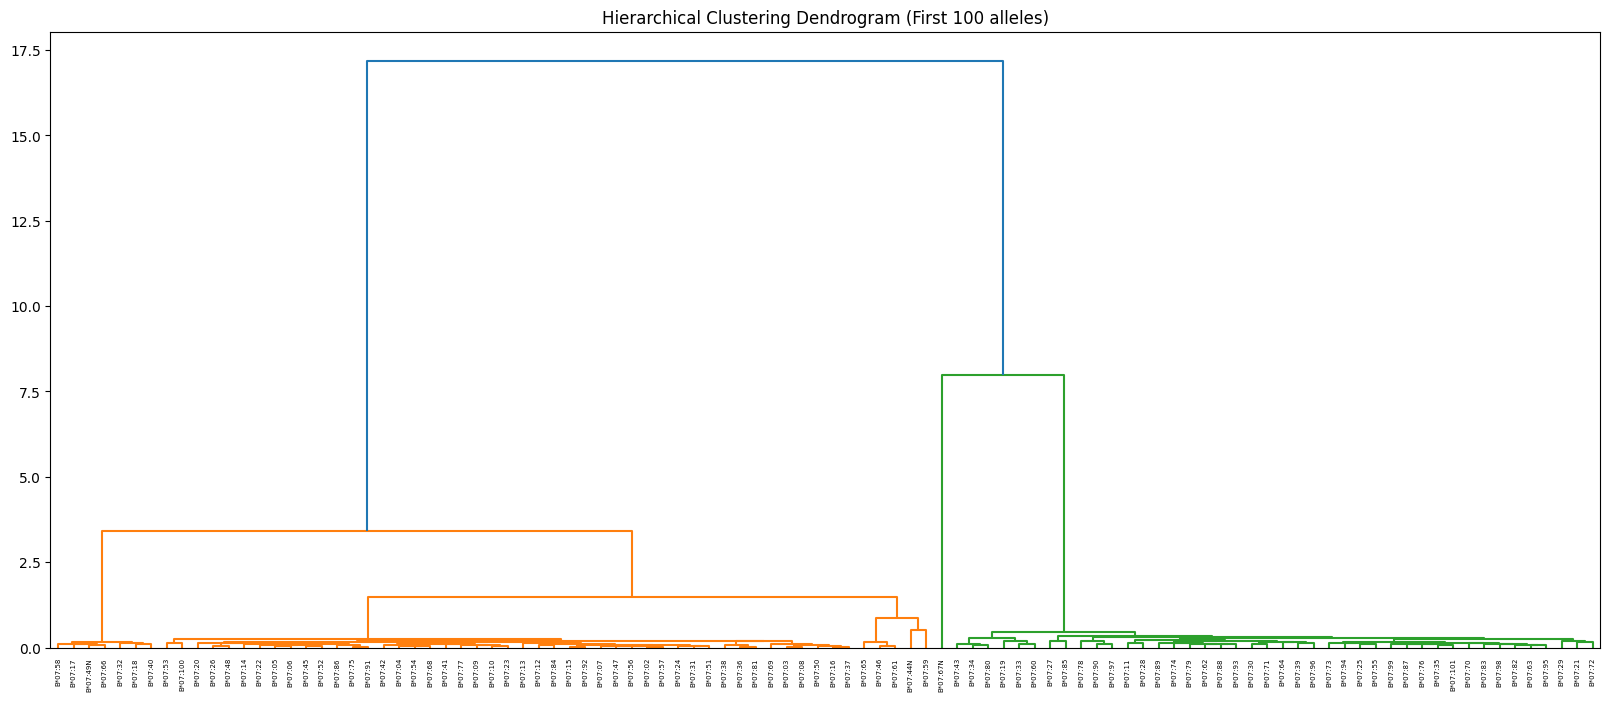

In [9]:
# Hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Limit to first 100 alleles for visibility
subset_embeddings = list(embeddings.items())[:100]
subset_keys, subset_values = zip(*subset_embeddings)
X_subset = np.array(subset_values)

# Perform hierarchical clustering
Z_subset = linkage(X_subset, method='ward')

# Plot dendrogram
plt.figure(figsize=(20, 8))
dendrogram(Z_subset, labels=subset_keys, orientation='top', leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (First 100 alleles)')
plt.show()

In [10]:
# Clustering evaluation metrics
import numpy as np
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix

# Example cluster labels from unsupervised clustering and true serological labels
cluster_labels = df['cluster'].values
true_labels = df['serological'].values
# Convert true labels to integers
true_labels = pd.Categorical(true_labels).codes

# Compute Adjusted Rand Index (ARI)
ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

# Compute Normalized Mutual Information (NMI)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# Create a contingency table (confusion matrix)
contingency = confusion_matrix(true_labels, cluster_labels)
print("\nContingency Table shape:", contingency.shape)

Adjusted Rand Index (ARI): 0.1306
Normalized Mutual Information (NMI): 0.3189

Contingency Table shape: (36, 36)


In [11]:
# Clustering accuracy using Hungarian algorithm
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def clustering_accuracy(true_labels, cluster_labels):
    """
    Compute clustering accuracy using the Hungarian algorithm for optimal label mapping.

    Parameters:
        true_labels (np.ndarray): Ground truth class labels.
        cluster_labels (np.ndarray): Predicted cluster labels from unsupervised clustering.

    Returns:
        float: Clustering accuracy as the proportion of correctly mapped labels.
    """
    # Compute the contingency table between true and predicted labels
    cont_matrix = confusion_matrix(true_labels, cluster_labels)
    
    # Apply the Hungarian algorithm (linear_sum_assignment) on the negated contingency table.
    # This finds the optimal assignment that maximizes the number of matches.
    row_ind, col_ind = linear_sum_assignment(-cont_matrix)
    
    # Sum the counts from the contingency table for the optimal assignment
    total_correct = cont_matrix[row_ind, col_ind].sum()
    
    # Calculate the overall clustering accuracy
    accuracy = total_correct / np.sum(cont_matrix)
    return accuracy

# Example ground truth labels (serological labels)
true_labels = df['serological'].values
# Example clustering labels (obtained from an unsupervised clustering algorithm)
cluster_labels = df['cluster'].values
# Convert true labels to integers
true_labels = pd.Categorical(true_labels).codes

# Compute the clustering accuracy using the Hungarian algorithm
acc = clustering_accuracy(true_labels, cluster_labels)
print(f"Clustering Accuracy (Optimal Assignment): {acc:.4f}")

Clustering Accuracy (Optimal Assignment): 0.2565


In [12]:
# Save results
output_file = 'clustered_alleles_esm.csv'
df.to_csv(output_file, index=False)
print(f"Results saved to {output_file}")

# Save ESM embeddings for future use
embeddings_file = embeddings_dir / 'b_locus_esm_embeddings.pkl'
with open(embeddings_file, 'wb') as f:
    pickle.dump(embeddings, f)
print(f"\nESM embeddings saved to {embeddings_file}")

Results saved to clustered_alleles_esm.csv

ESM embeddings saved to /Users/dakdemir/Library/CloudStorage/OneDrive-NMDP/Year2025/Github/hla-protbert/data/embeddings/b_locus_esm_embeddings.pkl


In [14]:
# Compare with original ProtBERT embeddings if available
if protbert_embeddings_file.exists():
    with open(protbert_embeddings_file, 'rb') as f:
        try:
            protbert_embeddings = pickle.load(f)
        except ModuleNotFoundError as e:
            # Some pickles reference legacy numpy internal module paths (e.g. numpy._core.numeric).
            # Patch sys.modules to point those names to the current numpy objects and retry.
            import sys
            if 'np' not in globals():
                import numpy as np
            legacy_names = [
                'numpy._core.numeric',
                'numpy.core._multiarray_umath',
                'numpy._multiarray_umath'
            ]
            for name in legacy_names:
                if name not in sys.modules:
                    # Map to a sensible numpy submodule if available
                    target = getattr(np, 'core', np)
                    if hasattr(target, 'numeric'):
                        sys.modules[name] = target.numeric
                    else:
                        sys.modules[name] = target
            f.seek(0)
            protbert_embeddings = pickle.load(f)

    print(f"ProtBERT embeddings: {len(protbert_embeddings)} alleles")
    print(f"ESM embeddings: {len(embeddings)} alleles")

    # Compare embedding dimensions
    if protbert_embeddings and embeddings:
        protbert_dim = list(protbert_embeddings.values())[0].shape[0]
        esm_dim = list(embeddings.values())[0].shape[0]
        print(f"\nProtBERT embedding dimension: {protbert_dim}")
        print(f"ESM embedding dimension: {esm_dim}")
else:
    print("ProtBERT embeddings not found for comparison")

ProtBERT embeddings: 6584 alleles
ESM embeddings: 6584 alleles

ProtBERT embedding dimension: 1024
ESM embedding dimension: 1280
